### Предварительно обученная сеть, которая описывает сцены

Мы начали с классификации изображений, перешли к генерации изображений, а затем выполнили задачу генерации текста с помощью трансформеров. Теперь давайте посмотрим, сможем ли мы выполнить задачу, которая использует обработку естественного языка для аннотирования изображений. Зрение и язык — это два фундаментальных навыка в том, как люди воспринимают мир, а создание подписей к изображениям является отличным примером того, как глубокое обучение может выполнять задачи, которые когда-то считались решаемыми только человеком.

Мы будем использовать предварительно обученную модель преобразования изображений в текст, известную как BLIP, разработанную командой исследователей из Salesforce Research. BLIP является мультимодальной моделью; то есть она разработана для обработки различных типов данных (или модальностей) — текста и изображений, в данном случае — в качестве своего ввода.

BLIP был обучен на различных комбинациях изображений и текста, чтобы изучить отношения между ними. Он был обучен на больших наборах данных изображений и соответствующих им описательных предложений — например, «Полосатый кот облокотился на деревянный стол, одной лапой держит лазерную мышь, а другой — черный ноутбук». Перед обучением BLIP команда также выполнила некоторые предварительные методы обработки, чтобы отфильтровать определенные подписи из шумных данных в интернете и сгенерировать синтетические подписи для увеличения набора данных.

Поскольку модель обучена на парах изображений и подписей, как она может аннотировать изображения, которые она никогда раньше не видела? Набор данных изображений велик, но недостаточно велик, чтобы охватить каждое изображение, которое можно представить. На высоком уровне во время обучения изображение кодируется в вектор чисел, называемый встраиванием (embedding). Аналогично, соответствующая подпись также кодируется в другое встраивание. Эти значения сравниваются, чтобы определить, насколько изображения и подпись похожи, что итеративно обучает модель. Кроме того, у модели есть декодер, который генерирует догадки для подписи на основе изображения. В этом процессе есть еще много деталей, но мы стараемся не углубляться в них.

ПРИМЕЧАНИЕ: Для любопытных рекомендуется ознакомиться со статьей «BLIP: Bootstrapping Language Image Pre-training for Unified Vision-Language Understanding and Generation», доступной по ссылке https://arxiv.org/pdf/2201.12086.pdf.

Для выполнения инференса пользователю нужно только использовать части модели для кодирования изображений и декодирования текста, чтобы генерировать текст. Модель для создания подписей состоит из двух частей; первая половина модели — это кодировщик изображений, который учится создавать «описательные» числовые представления сцены (кот Табби, лазерная мышь, лапа). Это встраивание «кодирования» затем передается во вторую половину модели. Вторая половина — это текстовый декодер, который генерирует связное предложение, преобразуя это кодирование в текстовое представление. Полученный результат — это подпись модели, описывающая изображение.

Мы можем использовать то, что мы узнали из нашего модельного зоопарка, чтобы найти BLIP на Hugging Face.Мы можем загрузить процессор для изображения и саму модель:

In [1]:
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

In [2]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large")

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

C:\Users\Админ\Desktop\NN_1\nn_env\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Админ\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, 

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Мы также определим вспомогательную функцию, чтобы использовать их и выводить подпись:

In [3]:
def annotate_image(image: Image) -> None:
    display(image)
    inputs = processor(image, return_tensors="pt")
    out = model.generate(**inputs)
    print(processor.decode(out[0], skip_special_tokens=True))

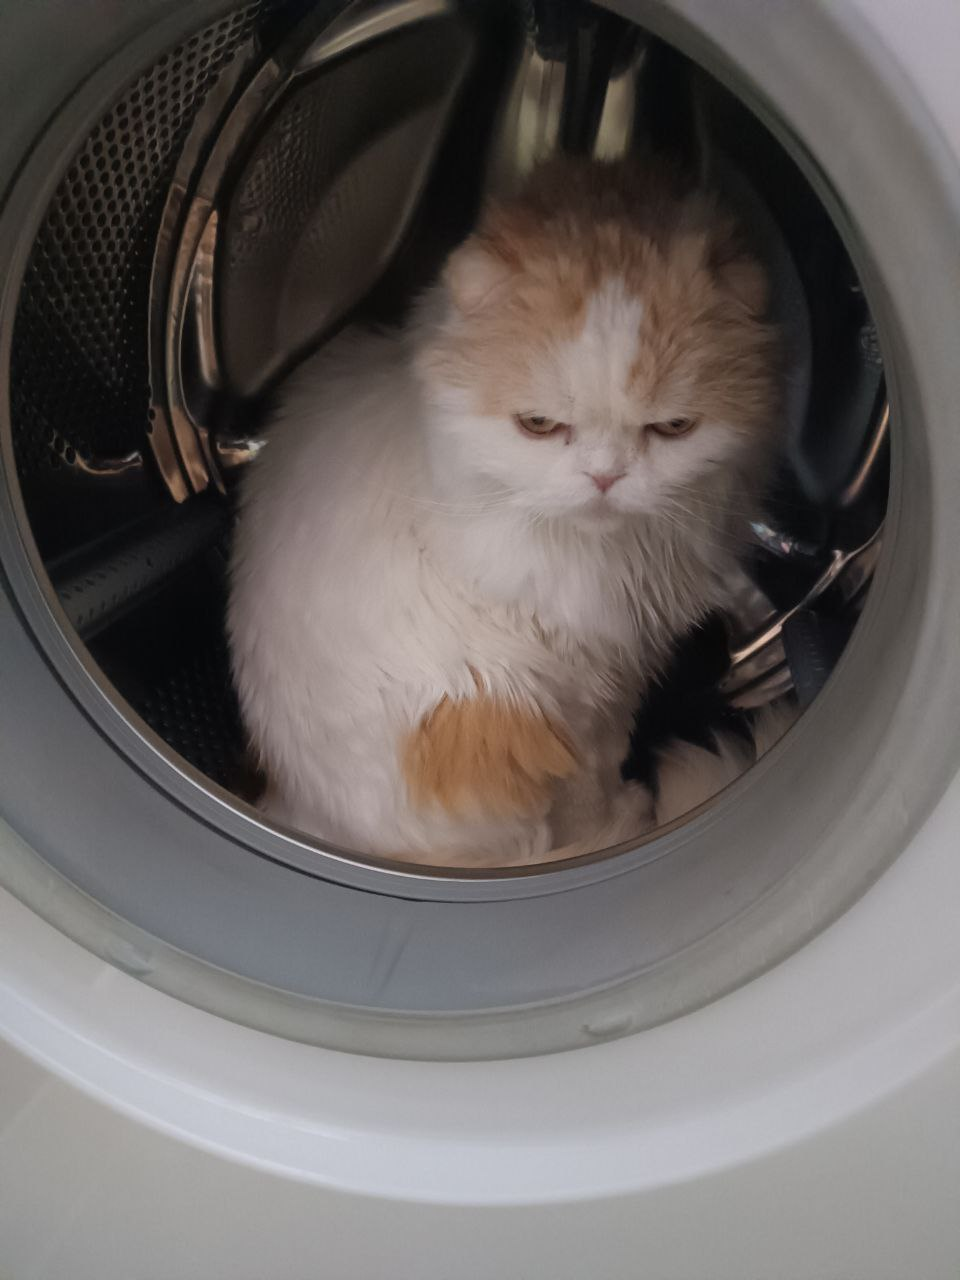

C:\Users\Админ\Desktop\NN_1\nn_env\lib\site-packages\transformers\generation\utils.py:1551: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


there is a cat that is sitting inside of a washing machine


In [4]:
annotate_image(Image.open(r"C:\Users\Админ\Desktop\py\DataScince\NN\learning\data\лёва.jpg"))

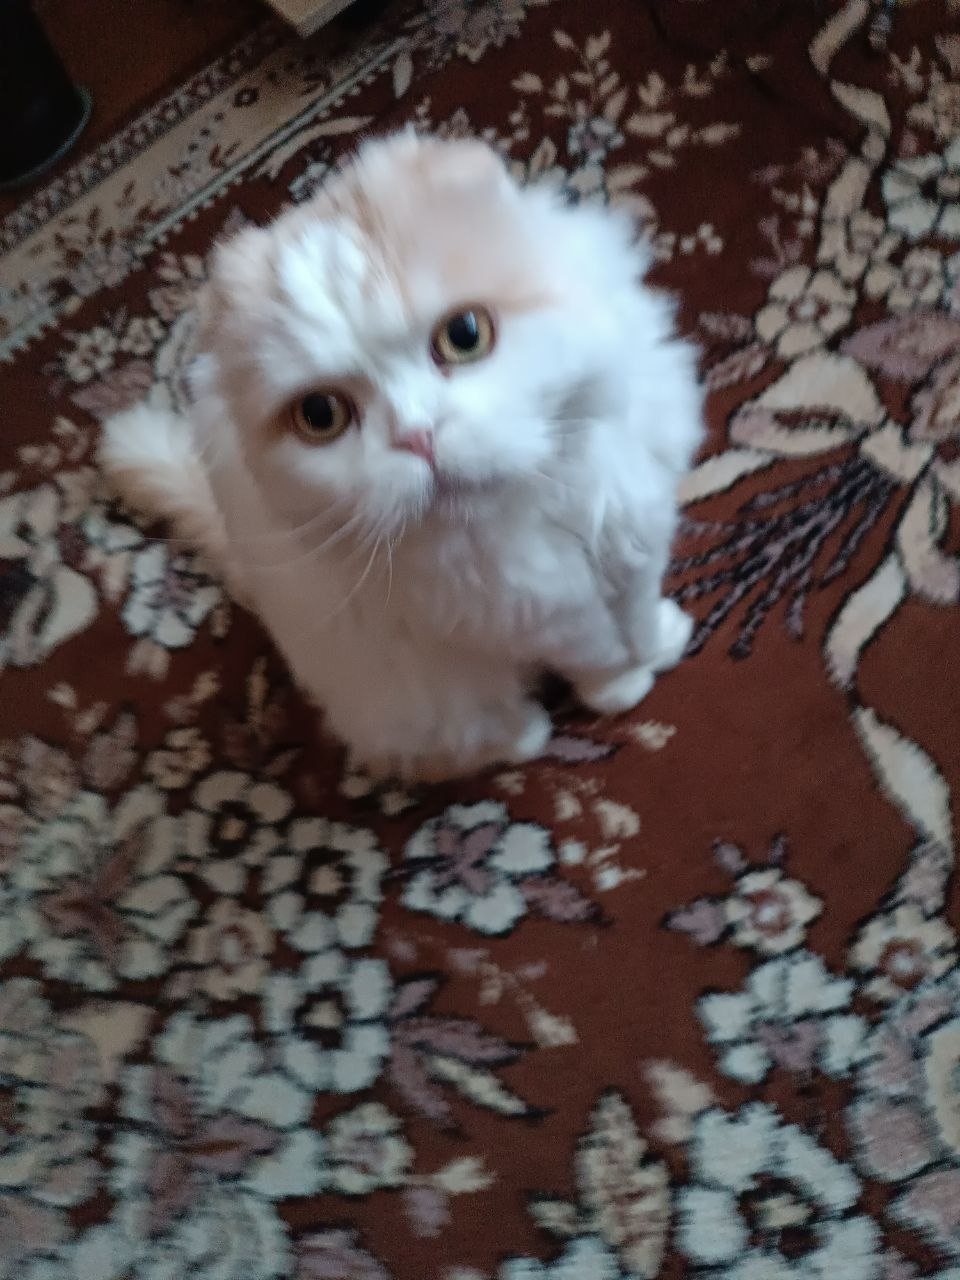

there is a white cat sitting on a rug on the floor


In [5]:
annotate_image(Image.open(r"C:\Users\Админ\Desktop\py\DataScince\NN\learning\data\лёва1.jpg"))

ОК!!! Вроде все работает)

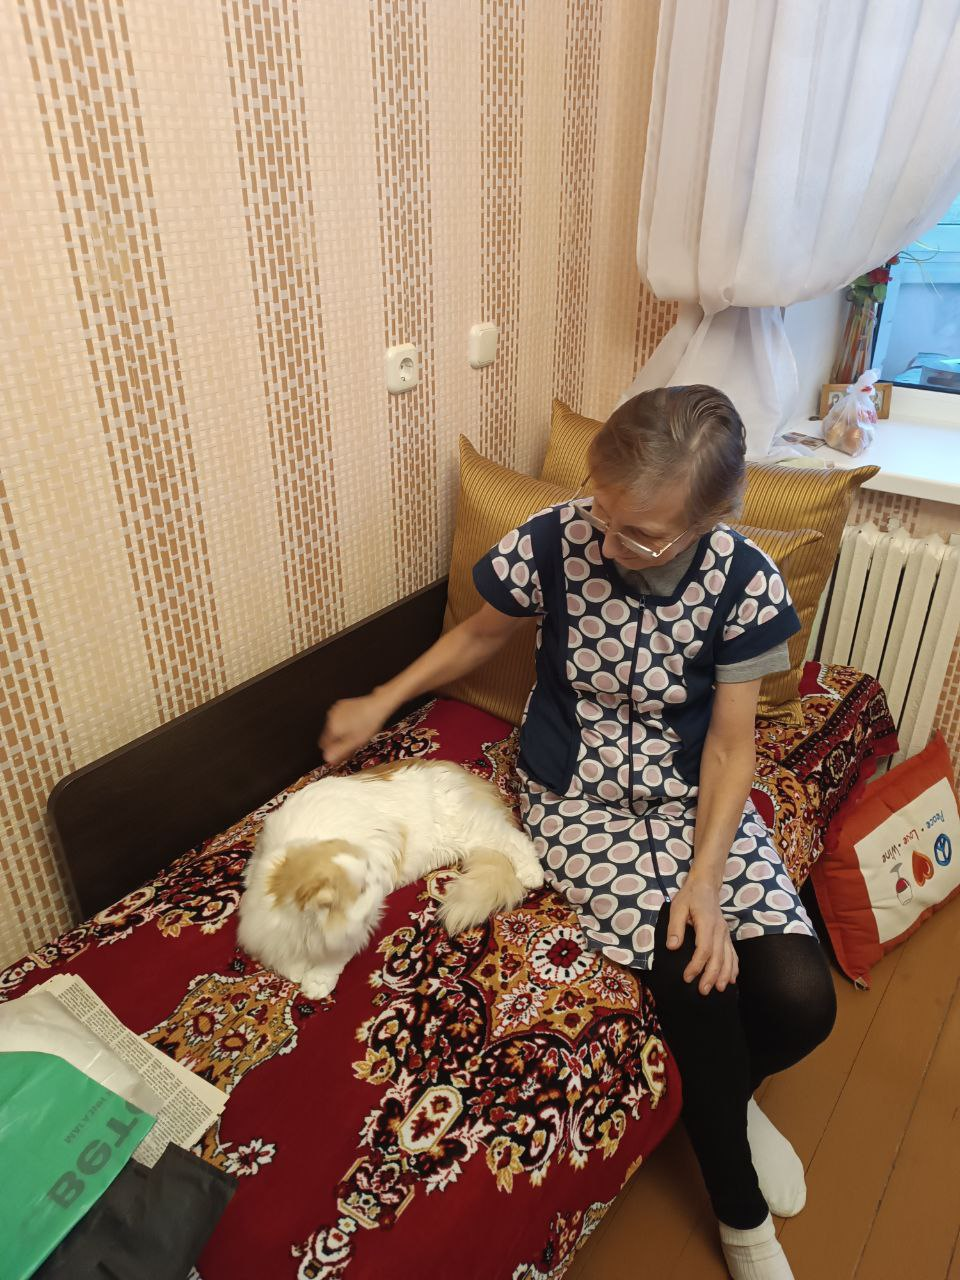

there is a woman sitting on a bed with a cat on it


In [7]:
annotate_image(Image.open(r"C:\Users\Админ\Desktop\py\DataScince\NN\learning\data\photo_2026-03-13_11-03-31.jpg"))